# Evaluation Results Visualization: Vision Granularity Impact on LIBERO

This notebook generates key figures for the paper:
- **Figure 2:** Success Rate vs. Training Progress (Checkpoint Steps) by Vision Granularity
- **Figure 3:** Language Dependency Gap (ΔSR) vs. Training Progress by Vision Granularity

## 1. Load Data from SQLite Database

In [1]:
%pip install pandas requests seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 8.9 MB/s  0:00:01eta 0:00:01m━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.9 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 8.9 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Add parent directory to path for imports
sys.path.append(str(Path.cwd().parent.parent))

from starVLA.eval.eval_database_helper import DatabaseHelper

# Set plotting style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'

## 2. Data Preprocessing

In [3]:
# Initialize database helper
db_path = '/home/sukai/Project/STAR_VLA_FIX/Fix_STARVLA_VLA_adapter/results/starvla_eval_results.db'
db_helper = DatabaseHelper(db_name=db_path)

# Load all evaluation results
df = db_helper.query_from_sql("SELECT * FROM EvalResult")

print(f"Loaded {len(df)} evaluation results from database")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Loaded 198000 evaluation results from database

Columns: ['eval_round_id', 'train_id', 'timestamp', 'checkpoint_step', 'model_arch', 'training_strategy', 'env_name', 'task_suite_name', 'problem_id', 'vision_granularity', 'instruction_type', 'instruction_value', 'success', 'seed', 'is_ood_visual', 'is_ood_language', 'max_completed_stage', 'total_stages', 'primary_interaction_object', 'failure_reason']

First few rows:


,eval_round_id,train_id,timestamp,checkpoint_step,model_arch,training_strategy,env_name,task_suite_name,problem_id,vision_granularity,instruction_type,instruction_value,success,seed,is_ood_visual,is_ood_language,max_completed_stage,total_stages,primary_interaction_object,failure_reason
0,LIBERO_PRELIM_TEST_VISION_HYPOTHESIS_V1,varying_image_gran_libero4in1_qwen_adapter,1769572960.0576,21000,QwenAdapter,varying_image_gran,libero,libero_goal,0,224,l,open the middle drawer of the cabinet,1,7,0,0,-1,-1,,
1,LIBERO_PRELIM_TEST_VISION_HYPOTHESIS_V1,varying_image_gran_libero4in1_qwen_adapter,1769572960.0576,21000,QwenAdapter,varying_image_gran,libero,libero_goal,1,224,l,open the middle drawer of the cabinet,0,7,0,0,-1,-1,,
2,LIBERO_PRELIM_TEST_VISION_HYPOTHESIS_V1,varying_image_gran_libero4in1_qwen_adapter,1769573952.92366,3000,QwenAdapter,varying_image_gran,libero,libero_goal,0,224,l,open the middle drawer of the cabinet,0,7,0,0,-1,-1,,
3,LIBERO_PRELIM_TEST_VISION_HYPOTHESIS_V1,varying_image_gran_libero4in1_qwen_adapter,1769573952.92366,3000,QwenAdapter,varying_image_gran,libero,libero_goal,1,224,l,open the middle drawer of the cabinet,0,7,0,0,-1,-1,,
4,LIBERO_PRELIM_TEST_VISION_HYPOTHESIS_V1,varying_image_gran_libero4in1_qwen_adapter,1769573958.25617,6000,QwenAdapter,varying_image_gran,libero,libero_goal,0,224,l,open the middle drawer of the cabinet,0,7,0,0,-1,-1,,


In [20]:
# convert success column all b'\x00' to 0 and b'\x01' to 1
df['success'] = df['success'].apply(lambda x: 1 if x == b'\x01' else 0 if x == b'\x00' else x)

In [21]:
# Group by model_arch and check success distribution
success_by_model = df.groupby('model_arch')['success'].value_counts(normalize=True).unstack().fillna(0)
print(success_by_model)

success             0         1
model_arch                     
QwenAdapter  0.374657  0.625343
QwenOFT      0.257020  0.742980


In [17]:
# database_helper query how many success == False 
false_success_count = db_helper.query_from_sql("SELECT COUNT(*) FROM EvalResult WHERE success = 0")

In [18]:
false_success_count

,COUNT(*)
0,16619


In [6]:
# filtering, only keep eval_round_id == "LIBERO_PRELIM_TEST_VISION_HYPOTHESIS_V1"
df = df[df['eval_round_id'] == "LIBERO_PRELIM_TEST_VISION_HYPOTHESIS_V1"]
print(f"After filtering, {len(df)} evaluation results remain.")


After filtering, 198000 evaluation results remain.


## 3. Figure 2: Success Rate vs. Training Progress by Vision Granularity

This figure shows how model performance improves during training across different visual granularities.

In [25]:
# Convert success to integer (0 or 1)
df['success'] = df['success'].astype(int)

# Convert vision_granularity to integer for proper sorting
df['vision_granularity_int'] = df['vision_granularity'].astype(int)

# Create categorical column for Vision Granularity (sorted High to Low)
# Get unique values and sort in descending order (High -> Low)
vision_gran_values = sorted(df['vision_granularity_int'].unique(), reverse=True)
df['Vision Granularity'] = pd.Categorical(
    df['vision_granularity_int'],
    categories=vision_gran_values,
    ordered=True
)

# Map instruction_type to readable labels
instruction_map = {
    'l': 'With Instruction',
    'no_lang': 'Null Instruction'
}
df['Instruction Type'] = df['instruction_type'].map(instruction_map)

# Create a readable Model name by combining model_arch and training_strategy
df['Model'] = df['model_arch'] + ' (' + df['training_strategy'] + ')'

print(f"\nUnique Vision Granularities (sorted High to Low): {vision_gran_values}")
print(f"Unique Instruction Types: {df['Instruction Type'].unique()}")
print(f"Unique Models: {df['Model'].unique()}")
print(f"\nData shape: {df.shape}")
df[['vision_granularity', 'vision_granularity_int', 'Vision Granularity', 'Instruction Type', 'Model', 'success']].head()


Unique Vision Granularities (sorted High to Low): [np.int64(224), np.int64(112), np.int64(32)]
Unique Instruction Types: <StringArray>
['With Instruction', 'Null Instruction']
Length: 2, dtype: str
Unique Models: <StringArray>
['QwenAdapter (varying_image_gran)', 'QwenOFT (varying_image_gran)']
Length: 2, dtype: str

Data shape: (198000, 24)


,vision_granularity,vision_granularity_int,Vision Granularity,Instruction Type,Model,success
0,224,224,224,With Instruction,QwenAdapter (varying_image_gran),1
1,224,224,224,With Instruction,QwenAdapter (varying_image_gran),0
2,224,224,224,With Instruction,QwenAdapter (varying_image_gran),0
3,224,224,224,With Instruction,QwenAdapter (varying_image_gran),0
4,224,224,224,With Instruction,QwenAdapter (varying_image_gran),0


## 4. Figure 3: Language Dependency Gap (ΔSR) vs. Training Progress

This figure shows how the gap between "With Instruction" and "Null Instruction" changes during training across different visual granularities.

/tmp/ipykernel_1092039/1262051233.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_with_instruction = df[df['model_arch'] == 'QwenOFT'][df['Instruction Type'] == 'With Instruction'].copy()


Success rates by Training Progress and Vision Granularity (With Instruction):
   model_arch  checkpoint_step  vision_granularity_int  Success Rate  \
0     QwenOFT             3000                      32        0.0065   
1     QwenOFT             3000                     112        0.0125   
2     QwenOFT             3000                     224        0.0060   
3     QwenOFT             6000                      32        0.4600   
4     QwenOFT             6000                     112        0.4670   
5     QwenOFT             6000                     224        0.4705   
6     QwenOFT             9000                      32        0.6140   
7     QwenOFT             9000                     112        0.6620   
8     QwenOFT             9000                     224        0.6540   
9     QwenOFT            12000                      32        0.6910   
10    QwenOFT            12000                     112        0.6935   
11    QwenOFT            12000                     224    

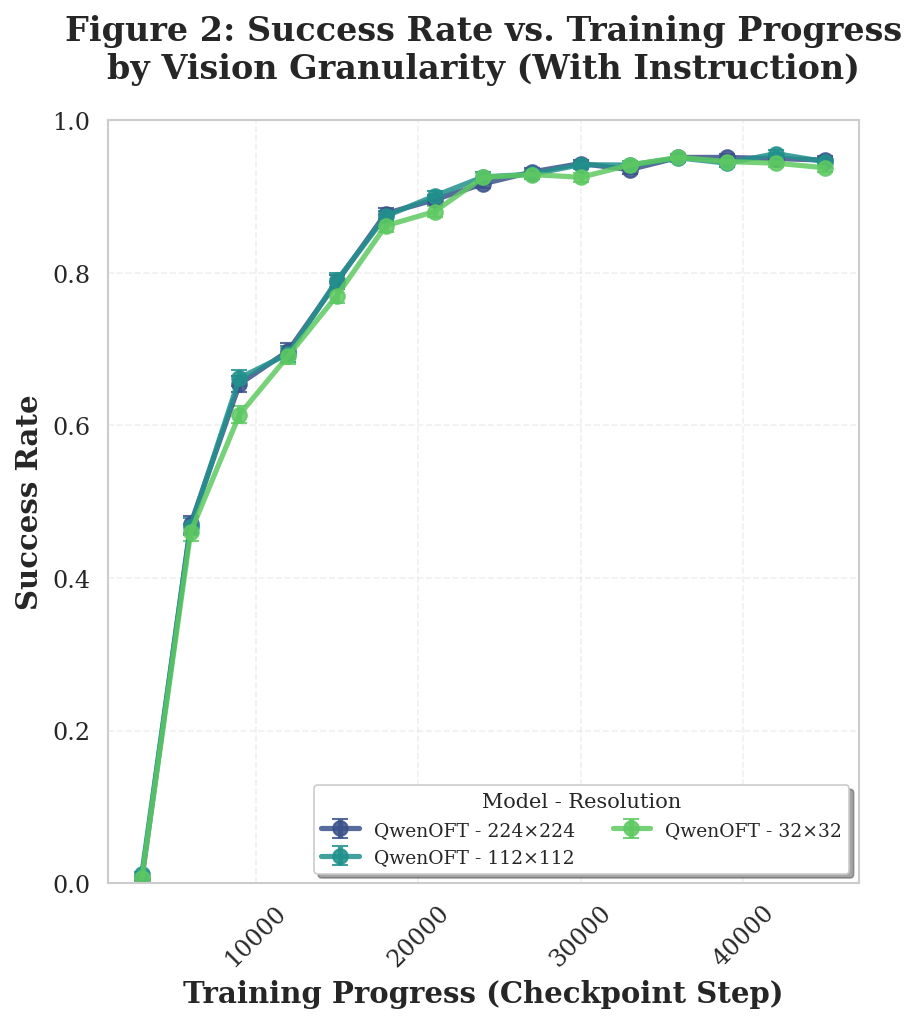


Figure 2 saved as 'figure2_success_rate_vs_training_progress.png'


In [35]:
# Filter for standard instruction only ("l" -> "With Instruction")
df_with_instruction = df[df['model_arch'] == 'QwenOFT'][df['Instruction Type'] == 'With Instruction'].copy()

# Calculate success rate by Model Arch, Checkpoint Step, and Vision Granularity
success_rate_by_progress = df_with_instruction.groupby(
    ['model_arch', 'checkpoint_step', 'vision_granularity_int']
)['success'].agg(['mean', 'sem', 'count']).reset_index()

success_rate_by_progress.rename(columns={'mean': 'Success Rate'}, inplace=True)

print("Success rates by Training Progress and Vision Granularity (With Instruction):")
print(success_rate_by_progress)

# Get unique model architectures and checkpoint steps
unique_model_archs = df_with_instruction['model_arch'].unique()
checkpoint_steps = sorted(df_with_instruction['checkpoint_step'].unique())

print(f"\nUnique Model Architectures: {unique_model_archs}")
print(f"Checkpoint Steps: {checkpoint_steps}")
print(f"Vision Granularities: {vision_gran_values}")

# Define color palette for vision granularities (from fine to coarse)
# Use a gradient from dark to light
colors = sns.color_palette("viridis", n_colors=len(vision_gran_values))
color_map = {gran: colors[i] for i, gran in enumerate(vision_gran_values)}

# Create Figure 2: Success Rate vs Training Progress
# Plot all model architectures in the same figure
fig, ax = plt.subplots(figsize=(6, 7))

for model_arch in unique_model_archs:
    for vision_gran in vision_gran_values:
        model_data = success_rate_by_progress[
            (success_rate_by_progress['model_arch'] == model_arch) &
            (success_rate_by_progress['vision_granularity_int'] == vision_gran)
        ].sort_values('checkpoint_step')
        
        if len(model_data) > 0:
            # Create label combining model and vision granularity
            label = f'{model_arch} - {vision_gran}×{vision_gran}'
            
            # Use different line styles for different models
            linestyle = '-' if model_arch == unique_model_archs[0] else '--'
            
            # Plot line with error bars (SEM)
            ax.errorbar(
                model_data['checkpoint_step'],
                model_data['Success Rate'],
                yerr=model_data['sem'],
                marker='o',
                markersize=7,
                linewidth=2.5,
                linestyle=linestyle,
                capsize=4,
                label=label,
                color=color_map[vision_gran],
                alpha=0.85
            )

# Formatting
ax.set_xlabel('Training Progress (Checkpoint Step)', fontsize=14, fontweight='bold')
ax.set_ylabel('Success Rate', fontsize=14, fontweight='bold')
ax.set_title('Figure 2: Success Rate vs. Training Progress\nby Vision Granularity (With Instruction)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, 1.0)
ax.legend(title='Model - Resolution', fontsize=9, title_fontsize=10, 
          frameon=True, shadow=True, loc='best', ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')

# Format x-axis to show checkpoint steps nicely
ax.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('figure2_success_rate_vs_training_progress.png', bbox_inches='tight')
plt.show()

print(f"\nFigure 2 saved as 'figure2_success_rate_vs_training_progress.png'")

## 5. Quantitative Analysis: Language Dependency Gap

Calculate the exact gap values for each model and vision granularity.

Success rates by Training Progress, Vision Granularity, and Instruction Type:
    checkpoint_step  vision_granularity_int  Instruction Type  Success Rate  \
0              3000                      32  Null Instruction        0.0000   
1              3000                      32  With Instruction        0.0065   
2              3000                     112  Null Instruction        0.0000   
3              3000                     112  With Instruction        0.0125   
4              3000                     224  Null Instruction        0.0000   
..              ...                     ...               ...           ...   
85            45000                      32  With Instruction        0.9375   
86            45000                     112  Null Instruction        0.3500   
87            45000                     112  With Instruction        0.9455   
88            45000                     224  Null Instruction        0.3850   
89            45000                     224  With Ins

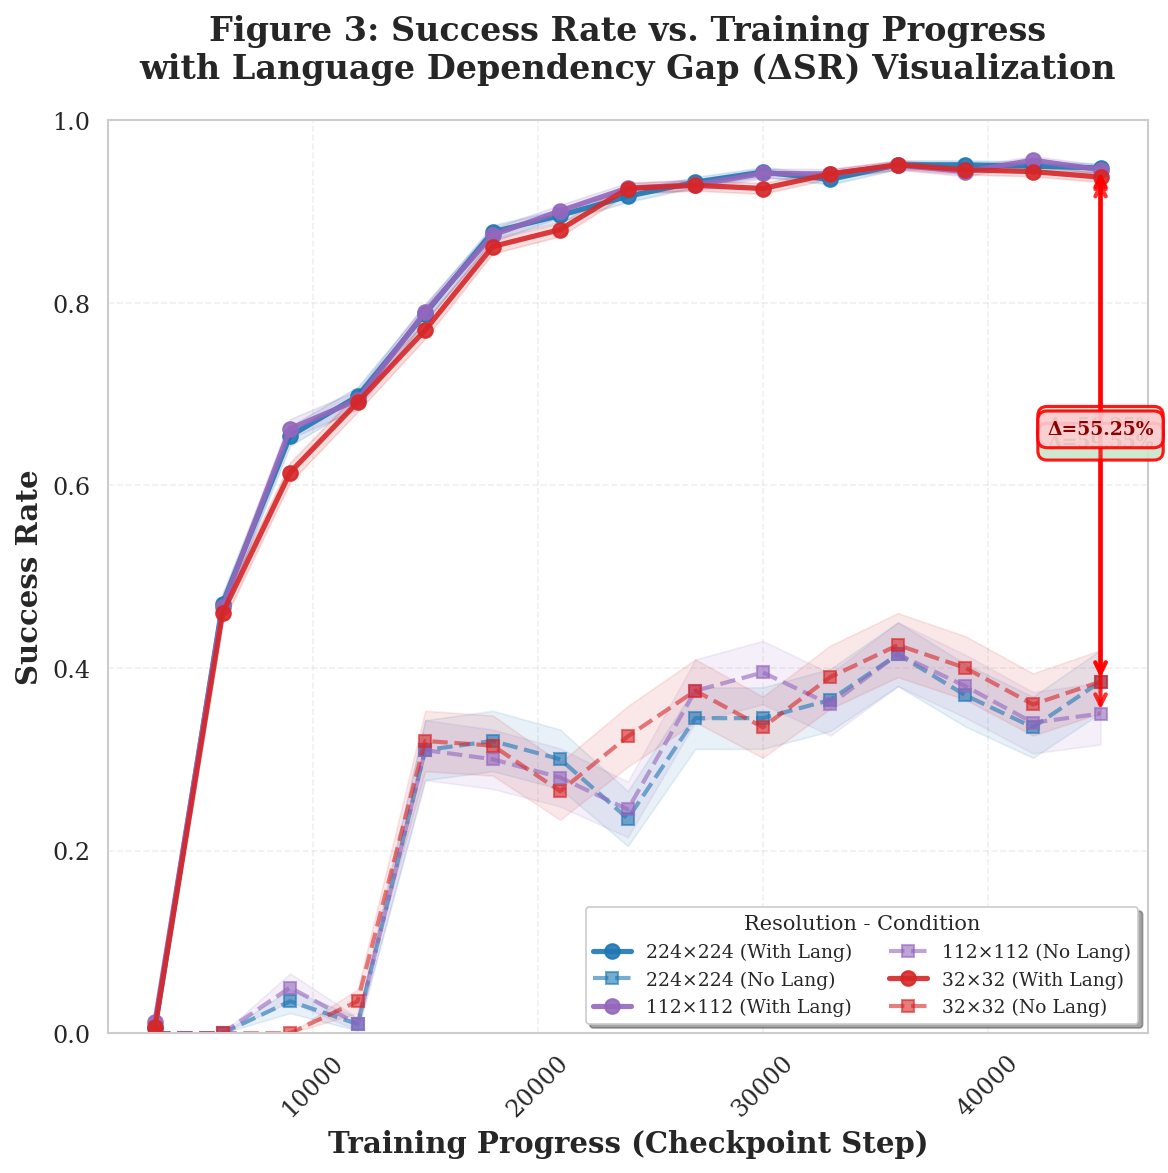


Figure 3 saved as 'figure3_language_gap_vs_training_progress.png'


In [34]:
# Calculate success rate by Checkpoint Step, Vision Granularity, and Instruction Type
# Aggregate across all model architectures
success_rate_by_instruction_progress = df[df['model_arch'] == 'QwenOFT'].groupby(
    ['checkpoint_step', 'vision_granularity_int', 'Instruction Type']
)['success'].agg(['mean', 'sem', 'count']).reset_index()

success_rate_by_instruction_progress.rename(columns={'mean': 'Success Rate'}, inplace=True)

print("Success rates by Training Progress, Vision Granularity, and Instruction Type:")
print(success_rate_by_instruction_progress)

# Define distinct color palette for vision granularities
# Use highly distinguishable colors
vision_colors = {
    224: '#1f77b4',  # Blue
    128: '#ff7f0e',  # Orange
    64: '#2ca02c',   # Green
    32: '#d62728',   # Red
}

# If you have different granularities, adjust accordingly
# Make sure all vision_gran_values are in the color map
for gran in vision_gran_values:
    if gran not in vision_colors:
        # Add additional colors if needed
        additional_colors = ['#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
        vision_colors[gran] = additional_colors[len(vision_colors) - 4]

# Create Figure 3: Success Rate with Language Dependency Gap Visualization
fig, ax = plt.subplots(figsize=(8, 8))

# Plot both With Instruction and Null Instruction lines
for vision_gran in vision_gran_values:
    # Get data for with instruction
    with_inst_data = success_rate_by_instruction_progress[
        (success_rate_by_instruction_progress['vision_granularity_int'] == vision_gran) &
        (success_rate_by_instruction_progress['Instruction Type'] == 'With Instruction')
    ].sort_values('checkpoint_step')
    
    # Get data for null instruction
    null_inst_data = success_rate_by_instruction_progress[
        (success_rate_by_instruction_progress['vision_granularity_int'] == vision_gran) &
        (success_rate_by_instruction_progress['Instruction Type'] == 'Null Instruction')
    ].sort_values('checkpoint_step')
    
    if len(with_inst_data) > 0:
        # Plot With Instruction line (solid)
        label_with = f'{vision_gran}×{vision_gran} (With Lang)'
        ax.plot(
            with_inst_data['checkpoint_step'],
            with_inst_data['Success Rate'],
            marker='o',
            markersize=7,
            linewidth=2.5,
            linestyle='-',
            label=label_with,
            color=vision_colors[vision_gran],
            alpha=0.9
        )
        
        # Add error bars for with instruction
        ax.fill_between(
            with_inst_data['checkpoint_step'],
            with_inst_data['Success Rate'] - with_inst_data['sem'],
            with_inst_data['Success Rate'] + with_inst_data['sem'],
            color=vision_colors[vision_gran],
            alpha=0.15
        )
    
    if len(null_inst_data) > 0:
        # Plot Null Instruction line (dashed)
        label_null = f'{vision_gran}×{vision_gran} (No Lang)'
        ax.plot(
            null_inst_data['checkpoint_step'],
            null_inst_data['Success Rate'],
            marker='s',
            markersize=6,
            linewidth=2,
            linestyle='--',
            label=label_null,
            color=vision_colors[vision_gran],
            alpha=0.6
        )
        
        # Add error bars for null instruction
        ax.fill_between(
            null_inst_data['checkpoint_step'],
            null_inst_data['Success Rate'] - null_inst_data['sem'],
            null_inst_data['Success Rate'] + null_inst_data['sem'],
            color=vision_colors[vision_gran],
            alpha=0.1
        )

# Add arrows and delta annotations for the final checkpoint
for vision_gran in vision_gran_values:
    # Get final checkpoint data
    with_inst_final = success_rate_by_instruction_progress[
        (success_rate_by_instruction_progress['vision_granularity_int'] == vision_gran) &
        (success_rate_by_instruction_progress['Instruction Type'] == 'With Instruction')
    ].sort_values('checkpoint_step').iloc[-1]
    
    null_inst_final = success_rate_by_instruction_progress[
        (success_rate_by_instruction_progress['vision_granularity_int'] == vision_gran) &
        (success_rate_by_instruction_progress['Instruction Type'] == 'Null Instruction')
    ].sort_values('checkpoint_step').iloc[-1]
    
    checkpoint = with_inst_final['checkpoint_step']
    with_sr = with_inst_final['Success Rate']
    null_sr = null_inst_final['Success Rate']
    delta_sr = with_sr - null_sr
    
    # Draw vertical arrow showing the gap
    ax.annotate('', 
                xy=(checkpoint, with_sr), 
                xytext=(checkpoint, null_sr),
                arrowprops=dict(arrowstyle='<->', color='red', lw=2, alpha=0.8))
    
    # Determine annotation style based on delta value and granularity
    if vision_gran == min(vision_gran_values):  # Coarsest resolution
        bbox_color = '#FFCDD2'  # Light red
        text_color = 'darkred'
    elif delta_sr > 0.015:
        bbox_color = '#C8E6C9'  # Light green
        text_color = 'darkgreen'
    else:
        bbox_color = '#FFF9C4'  # Light yellow
        text_color = 'darkorange'
    
    # Add delta text annotation
    mid_y = (with_sr + null_sr) / 2
    ax.text(checkpoint, mid_y, f'Δ={delta_sr:.2%}',
            ha='center', va='center', 
            fontsize=9, fontweight='bold',
            color=text_color,
            bbox=dict(boxstyle='round,pad=0.5', 
                     facecolor=bbox_color, 
                     edgecolor='red', 
                     linewidth=1.5,
                     alpha=0.9))

# Formatting
ax.set_xlabel('Training Progress (Checkpoint Step)', fontsize=14, fontweight='bold')
ax.set_ylabel('Success Rate', fontsize=14, fontweight='bold')
ax.set_title('Figure 3: Success Rate vs. Training Progress\nwith Language Dependency Gap (ΔSR) Visualization', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, 1.0)
ax.legend(title='Resolution - Condition', fontsize=9, title_fontsize=10, 
          frameon=True, shadow=True, loc='best', ncol=2)
ax.grid(True, alpha=0.3, linestyle='--')

# Format x-axis
ax.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('figure3_language_gap_vs_training_progress.png', bbox_inches='tight')
plt.show()

print(f"\nFigure 3 saved as 'figure3_language_gap_vs_training_progress.png'")

## 6. Additional Statistics

Display dataset statistics and distribution information.

In [ ]:
# Calculate the gap between With Instruction and Null Instruction
gap_analysis = []

for model in unique_models:
    model_data = success_rate_by_instruction[success_rate_by_instruction['Model'] == model]
    
    for vision_gran in vision_gran_values:
        with_inst_rate = model_data[
            (model_data['vision_granularity_int'] == vision_gran) & 
            (model_data['Instruction Type'] == 'With Instruction')
        ]['Success Rate'].values
        
        null_inst_rate = model_data[
            (model_data['vision_granularity_int'] == vision_gran) & 
            (model_data['Instruction Type'] == 'Null Instruction')
        ]['Success Rate'].values
        
        if len(with_inst_rate) > 0 and len(null_inst_rate) > 0:
            gap = with_inst_rate[0] - null_inst_rate[0]
            gap_analysis.append({
                'Model': model,
                'Vision Granularity': vision_gran,
                'With Instruction SR': with_inst_rate[0],
                'Null Instruction SR': null_inst_rate[0],
                'Language Gap': gap,
                'Gap %': gap * 100
            })

gap_df = pd.DataFrame(gap_analysis)
print("\nLanguage Dependency Gap Analysis:")
print("=" * 80)
print(gap_df.to_string(index=False))

# Summary statistics
print("\n\nSummary Statistics:")
print("=" * 80)
for model in unique_models:
    model_gaps = gap_df[gap_df['Model'] == model]
    print(f"\n{model}:")
    print(f"  Average Gap: {model_gaps['Language Gap'].mean():.3f} ({model_gaps['Gap %'].mean():.1f}%)")
    print(f"  Max Gap: {model_gaps['Language Gap'].max():.3f} at {model_gaps.loc[model_gaps['Language Gap'].idxmax(), 'Vision Granularity']}×{model_gaps.loc[model_gaps['Language Gap'].idxmax(), 'Vision Granularity']}")
    print(f"  Min Gap: {model_gaps['Language Gap'].min():.3f} at {model_gaps.loc[model_gaps['Language Gap'].idxmin(), 'Vision Granularity']}×{model_gaps.loc[model_gaps['Language Gap'].idxmin(), 'Vision Granularity']}")

In [ ]:
# Dataset statistics
print("Dataset Statistics:")
print("=" * 80)
print(f"Total number of evaluation runs: {len(df)}")
print(f"Number of unique models: {len(df['Model'].unique())}")
print(f"Number of unique vision granularities: {len(vision_gran_values)}")
print(f"Number of unique instruction types: {len(df['Instruction Type'].unique())}")

print("\n\nDistribution of evaluations:")
print("-" * 80)
distribution = df.groupby(['Model', 'Vision Granularity', 'Instruction Type']).size().reset_index(name='Count')
print(distribution.to_string(index=False))

print("\n\nOverall success rates by condition:")
print("-" * 80)
overall_success = df.groupby(['Model', 'Vision Granularity', 'Instruction Type'])['success'].mean().reset_index()
overall_success.rename(columns={'success': 'Success Rate'}, inplace=True)
overall_success['Success Rate'] = overall_success['Success Rate'].round(3)
print(overall_success.to_string(index=False))

# Close database connection
db_helper.close()
print("\n\nDatabase connection closed.")